In [1]:
import os
from pathlib import Path
import base64

import cv2
import numpy as np
import matplotlib.pyplot as plt
import requests

from api_stable.mammography import MammographyDicom
from api_stable.study import MammographyStudy

In [2]:
study_folder = "/workspace/Data/vinDr/physionet.org/files/vindr-mammo/1.0.0/images/004426a40da27ef22a866538b772ac44/"
print(os.listdir(study_folder))

['index.html', '7197f7e6f5ca3b9821d0460dcdc975d3.dicom', '78b8a2f4b10790d6b2a11e081eaf209a.dicom', 'd3ae4a0aa59a608a2823c029e988985f.dicom', '265596e3534efced063b4e656b7bd64f.dicom']


In [3]:
study = MammographyStudy.from_folder(study_folder)

print(study.patient_name)
#print(study.study_date)
#print(study.study_uid)
print(study.is_complete)
print(study.missing_views)
print(study.number_of_images)


Found 4 DICOM files in /workspace/Data/vinDr/physionet.org/files/vindr-mammo/1.0.0/images/004426a40da27ef22a866538b772ac44


AttributeError: 'MammographyDicom' object has no attribute 'patient_name'

In [4]:
import numpy as np
import matplotlib.pyplot as plt

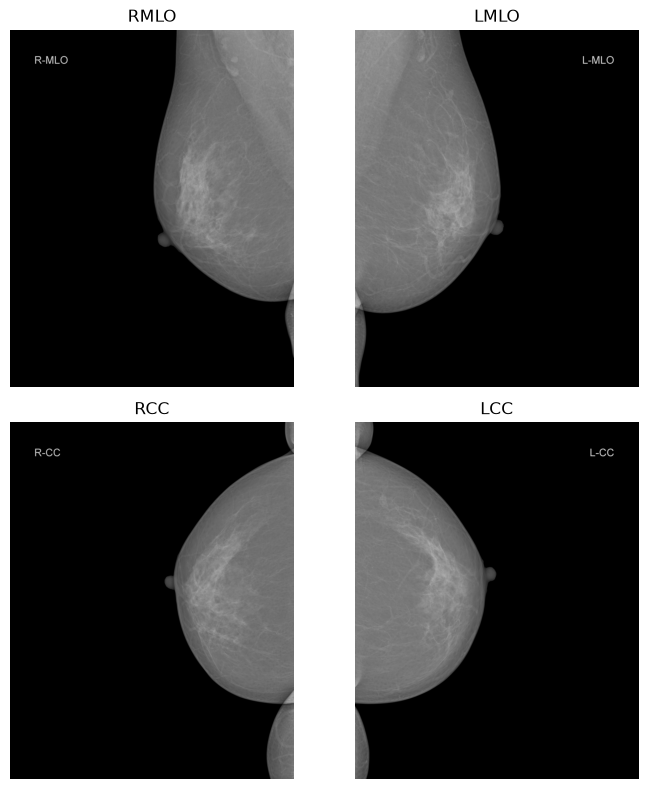

In [5]:
fig, ax = plt.subplots(2,2, figsize=(8,8))

ax[0,0].imshow(study.RMLO.image.pixel_array, cmap='gray')
ax[0,0].set_title(study.RMLO.view)
ax[0,0].axis('off')
plt.tight_layout()

ax[0,1].imshow(study.LMLO.image.pixel_array, cmap='gray')
ax[0,1].set_title(study.LMLO.view)
ax[0,1].axis('off')
plt.tight_layout()

ax[1,0].imshow(study.RCC.image.pixel_array, cmap='gray')
ax[1,0].set_title(study.RCC.view)
ax[1,0].axis('off')
plt.tight_layout()

ax[1,1].imshow(study.LCC.image.pixel_array, cmap='gray')
ax[1,1].set_title(study.LCC.view)
ax[1,1].axis('off')
plt.tight_layout()

plt.show()


In [6]:
from services.studyService import StudyService

In [7]:
study = StudyService.load(study_folder)

print(StudyService.validate(study))
print(StudyService.is_valid(study))

print(f"Loaded study with {StudyService.count_images(study)} images.")
print(f"Views: {StudyService.list_views(study)}")


Found 4 DICOM files in /workspace/Data/vinDr/physionet.org/files/vindr-mammo/1.0.0/images/004426a40da27ef22a866538b772ac44
True
True
Loaded study with 4 images.
Views: [<View.RMLO: 'RMLO'>, <View.RCC: 'RCC'>, <View.LCC: 'LCC'>, <View.LMLO: 'LMLO'>]


In [8]:
dataset_folder = "/workspace/Data/vinDr/physionet.org/files/vindr-mammo/1.0.0/images/"

dataset = StudyService.load_dataset(dataset_folder)
print(dataset)

#print(f"Loaded study with {StudyService.count_images(study)} images.")
#print(f"Views: {StudyService.list_views(study)}")

Found 4 DICOM files in /workspace/Data/vinDr/physionet.org/files/vindr-mammo/1.0.0/images/00464e1a9bfd88d33466321e03a55c1a
Found 4 DICOM files in /workspace/Data/vinDr/physionet.org/files/vindr-mammo/1.0.0/images/008b8e61390fcb4c0873258c15b0a53a
Found 4 DICOM files in /workspace/Data/vinDr/physionet.org/files/vindr-mammo/1.0.0/images/00c3c05f7ff415d71fae16ae999c178d
Found 4 DICOM files in /workspace/Data/vinDr/physionet.org/files/vindr-mammo/1.0.0/images/003700f3c960e0b9bca2b8437c3dbf05
Found 2 DICOM files in /workspace/Data/vinDr/physionet.org/files/vindr-mammo/1.0.0/images/00fe39c6d1283a7bec1c3335f54e53d9
Found 4 DICOM files in /workspace/Data/vinDr/physionet.org/files/vindr-mammo/1.0.0/images/00d888649670af0a057b18fddbb42276
Found 4 DICOM files in /workspace/Data/vinDr/physionet.org/files/vindr-mammo/1.0.0/images/0089db766396d0df4406d46cd6107b58
Found 4 DICOM files in /workspace/Data/vinDr/physionet.org/files/vindr-mammo/1.0.0/images/006f2e9cb3256c02fe82a7ff29af6260
Found 4 DICOM fi

In [9]:
print(dataset[0])

<MammographyStudy images=4 views=[RCC, LMLO, LCC, RMLO]>
